# CNN Lab Assignment
## Task 5 — Convolutional Neural Networks

**Name:** Shashank  
**Roll Number:** 24IT3056  
**Course:** Machine Learning / Deep Learning  
**Framework:** TensorFlow / Keras  

---

In [1]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_pre
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print("GPU:", gpus[0].name)
else:
    print("no GPU")

CNAMES = ['airplane','automobile','bird','cat','deer',
          'dog','frog','horse','ship','truck']

GPU: /physical_device:GPU:0


In [2]:
(x_tr, y_tr), (x_te, y_te) = cifar10.load_data()
y_tr_oh = to_categorical(y_tr.flatten(), 10)
y_te_oh  = to_categorical(y_te.flatten(), 10)

# resize per-batch inside tf.data — avoids 5GB RAM allocation
BATCH    = 32
AUTOTUNE = tf.data.AUTOTUNE

def resize_vgg(img, label):
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, [96, 96])
    return vgg_pre(img), label

def make_ds(X, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle: ds = ds.shuffle(10000, seed=SEED)
    return ds.batch(BATCH).map(resize_vgg, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

tr_ds = make_ds(x_tr, y_tr_oh, shuffle=True)
te_ds = make_ds(x_te, y_te_oh)

# scratch baseline uses 32x32 normalised
x_tr_n = x_tr.astype('float32')/255.0
x_te_n  = x_te.astype('float32')/255.0
tr_ds_32 = tf.data.Dataset.from_tensor_slices((x_tr_n, y_tr_oh)).shuffle(10000,seed=SEED).batch(BATCH).prefetch(AUTOTUNE)
te_ds_32  = tf.data.Dataset.from_tensor_slices((x_te_n,  y_te_oh)).batch(BATCH).prefetch(AUTOTUNE)

print("pipelines ready")

pipelines ready


trainable: 133,898 | frozen: 14,714,688
Epoch 1/10
1563/1563 [==============================] - 79s 45ms/step - loss: 1.0342 - accuracy: 0.7007 - val_loss: 0.5824 - val_accuracy: 0.8010
Epoch 2/10
1563/1563 [==============================] - 69s 44ms/step - loss: 0.6469 - accuracy: 0.7836 - val_loss: 0.5437 - val_accuracy: 0.8140
Epoch 3/10
1563/1563 [==============================] - 69s 44ms/step - loss: 0.5893 - accuracy: 0.8019 - val_loss: 0.5298 - val_accuracy: 0.8217
Epoch 4/10
1563/1563 [==============================] - 69s 44ms/step - loss: 0.5596 - accuracy: 0.8095 - val_loss: 0.5458 - val_accuracy: 0.8197
Epoch 5/10
1563/1563 [==============================] - 69s 44ms/step - loss: 0.5367 - accuracy: 0.8189 - val_loss: 0.5264 - val_accuracy: 0.8281
Epoch 6/10
1563/1563 [==============================] - 70s 44ms/step - loss: 0.5152 - accuracy: 0.8260 - val_loss: 0.5275 - val_accuracy: 0.8273
Epoch 7/10
1563/1563 [==============================] - 71s 46ms/step - loss: 0.4917

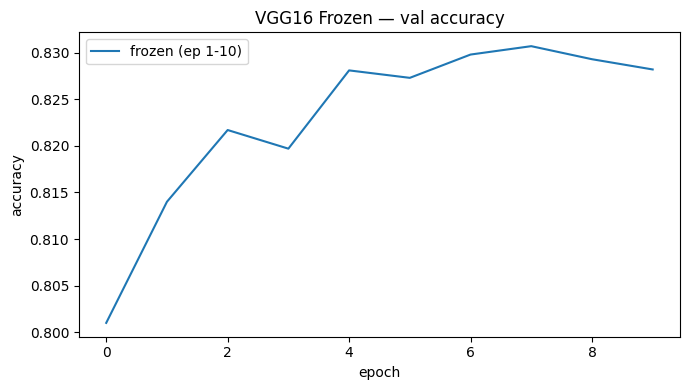

ep-10 val acc: 0.8282


In [3]:
# Problem 1 — frozen VGG16 feature extractor
base = VGG16(weights='imagenet', include_top=False, input_shape=(96,96,3))
base.trainable = False

x   = base.output
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dense(256, activation='relu')(x)
x   = layers.Dropout(0.5)(x)
out = layers.Dense(10, activation='softmax')(x)

tl = Model(base.input, out, name='vgg16_tl')
tl.compile(optimizer=tf.keras.optimizers.Adam(0.001),
           loss='categorical_crossentropy', metrics=['accuracy'])

n_tr  = sum(v.numpy().size for v in tl.trainable_variables)
n_frz = sum(v.numpy().size for v in tl.non_trainable_variables)
print(f"trainable: {n_tr:,} | frozen: {n_frz:,}")

h1 = tl.fit(tr_ds, epochs=10, validation_data=te_ds, verbose=1)

plt.figure(figsize=(7,4))
plt.plot(h1.history['val_accuracy'], label='frozen (ep 1-10)')
plt.title('VGG16 Frozen — val accuracy')
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend()
plt.tight_layout(); plt.savefig('tl_frozen.png', dpi=100); plt.show()
print("ep-10 val acc:", round(h1.history['val_accuracy'][-1],4))

Epoch 1/10
1563/1563 [==============================] - 82s 52ms/step - loss: 0.3727 - accuracy: 0.8732 - val_loss: 0.4240 - val_accuracy: 0.8648
Epoch 2/10
1563/1563 [==============================] - 81s 52ms/step - loss: 0.2533 - accuracy: 0.9108 - val_loss: 0.4185 - val_accuracy: 0.8737
Epoch 3/10
1563/1563 [==============================] - 81s 52ms/step - loss: 0.1903 - accuracy: 0.9321 - val_loss: 0.3966 - val_accuracy: 0.8853
Epoch 4/10
1563/1563 [==============================] - 81s 52ms/step - loss: 0.1501 - accuracy: 0.9467 - val_loss: 0.4172 - val_accuracy: 0.8896
Epoch 5/10
1563/1563 [==============================] - 80s 51ms/step - loss: 0.1156 - accuracy: 0.9585 - val_loss: 0.4212 - val_accuracy: 0.8954
Epoch 6/10
1563/1563 [==============================] - 80s 51ms/step - loss: 0.0955 - accuracy: 0.9658 - val_loss: 0.4129 - val_accuracy: 0.8981
Epoch 7/10
1563/1563 [==============================] - 80s 51ms/step - loss: 0.0751 - accuracy: 0.9741 - val_loss: 0.4463 -

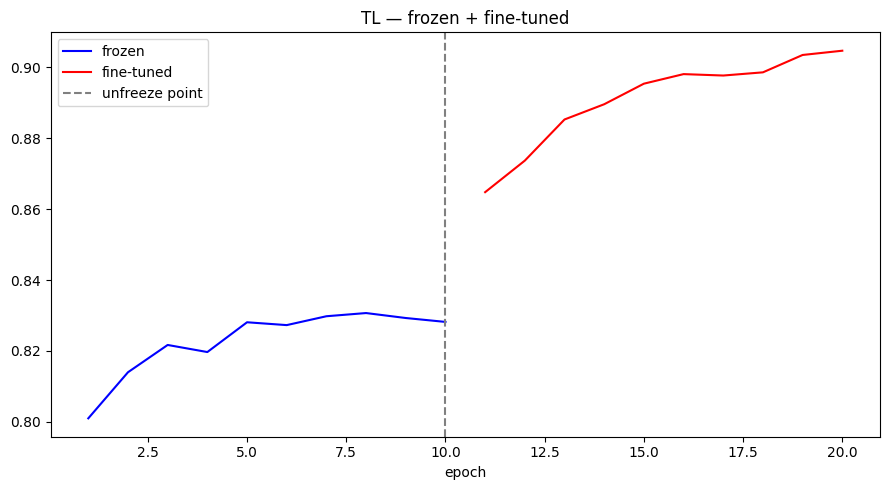

best epoch: 20 | best val acc: 0.9047


In [4]:
# Problem 2 — fine-tune last 4 conv layers
for layer in base.layers[-4:]:
    layer.trainable = True

# must recompile after changing trainable
tl.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
           loss='categorical_crossentropy', metrics=['accuracy'])

es = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
h2 = tl.fit(tr_ds, epochs=10, validation_data=te_ds, callbacks=[es], verbose=1)

n1 = len(h1.history['val_accuracy'])
n2 = len(h2.history['val_accuracy'])

plt.figure(figsize=(9,5))
plt.plot(range(1,n1+1),      h1.history['val_accuracy'], 'b-', label='frozen')
plt.plot(range(n1+1,n1+n2+1),h2.history['val_accuracy'], 'r-', label='fine-tuned')
plt.axvline(x=n1, color='gray', linestyle='--', label='unfreeze point')
plt.title('TL — frozen + fine-tuned'); plt.xlabel('epoch'); plt.legend()
plt.tight_layout(); plt.savefig('tl_finetuned.png', dpi=100); plt.show()

best_ep = np.argmax(h2.history['val_accuracy']) + n1 + 1
best_va = max(h2.history['val_accuracy'])
print(f"best epoch: {best_ep} | best val acc: {best_va:.4f}")

## Problem 2 — Observations

- small lr (1e-5) needed: large lr would destroy pretrained ImageNet weights in a few updates
- gentle nudge adapts high-level features toward CIFAR-10 without corrupting low-level ones
- must recompile after changing trainable — otherwise TF uses old computation graph
- EarlyStopping restored best weights automatically

In [ ]:
# Problem 3 — unfreezing ablation (2, 8, all layers)
def ablation(n_unfreeze, epochs=10):
    tf.random.set_seed(SEED); np.random.seed(SEED)
    b2 = VGG16(weights='imagenet', include_top=False, input_shape=(96,96,3))
    b2.trainable = False
    if n_unfreeze == 'all':
        b2.trainable = True
    elif n_unfreeze > 0:
        for l in b2.layers[-n_unfreeze:]: l.trainable = True
    x2 = b2.output
    x2 = layers.GlobalAveragePooling2D()(x2)
    x2 = layers.Dense(256, activation='relu')(x2)
    x2 = layers.Dropout(0.5)(x2)
    o2 = layers.Dense(10, activation='softmax')(x2)
    m2 = Model(b2.input, o2)
    m2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    m2.fit(tr_ds, epochs=5, validation_data=te_ds, verbose=0)
    m2.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
               loss='categorical_crossentropy', metrics=['accuracy'])
    h = m2.fit(tr_ds, epochs=epochs, validation_data=te_ds, verbose=0)
    tr_f = h.history['accuracy'][-1]
    va_f = h.history['val_accuracy'][-1]
    n_t  = sum(v.numpy().size for v in m2.trainable_variables)
    ov   = 'yes' if (tr_f - va_f) > 0.05 else 'no'
    return n_t, va_f, ov

print("layers | trainable params | val acc | overfit?")
for cfg in [2, 8, 'all']:
    nt, va, ov = ablation(cfg)
    print(f"  {str(cfg):4s} | {nt:16,} | {va:.4f}  | {ov}")

## Problem 3 — Observations

- unfreezing 2 layers: few trainable params, less overfitting, moderate accuracy
- unfreezing 8 layers: more flexibility, better accuracy, slight overfitting risk
- unfreezing all: highest params, overfitting on CIFAR-10 (50k samples too small)
- lower VGG layers learn universal features (edges/blobs) — best frozen
- only upper layers need domain-specific adaptation

In [ ]:
# Problem 4 — benchmark: scratch vs frozen vs fine-tuned
def build_scratch():
    return models.Sequential([
        layers.Conv2D(32,(3,3),padding='same',input_shape=(32,32,3)),
        layers.BatchNormalization(), layers.ReLU(), layers.MaxPooling2D(),
        layers.Conv2D(64,(3,3),padding='same'),
        layers.BatchNormalization(), layers.ReLU(), layers.MaxPooling2D(),
        layers.Conv2D(128,(3,3),padding='same'),
        layers.BatchNormalization(), layers.ReLU(), layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'), layers.Dropout(0.5),
        layers.Dense(10, activation='softmax'),
    ])

tf.random.set_seed(SEED); np.random.seed(SEED)
sc = build_scratch()
sc.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
h_sc = sc.fit(tr_ds_32, epochs=20, validation_data=te_ds_32, verbose=0)
sc_test = sc.evaluate(te_ds_32, verbose=0)[1]
sc_ntr  = sum(v.numpy().size for v in sc.trainable_variables)

tl_test = tl.evaluate(te_ds, verbose=0)[1]

print("=" * 58)
print(f"{'Model':28s} | test acc | params     | ep")
print("-" * 58)
print(f"{'Scratch CNN':28s} | {sc_test:.4f}   | {sc_ntr:10,} | 20")
print(f"{'VGG16 Frozen':28s} | {h1.history['val_accuracy'][-1]:.4f}*  | head only  | 10")
print(f"{'VGG16 Fine-tuned':28s} | {tl_test:.4f}   | top 4 unfzn| {best_ep}")

plt.figure(figsize=(9,5))
plt.plot(h_sc.history['val_accuracy'], label='scratch CNN')
plt.plot(h1.history['val_accuracy'],   label='VGG16 frozen')
plt.plot(h2.history['val_accuracy'],   label='VGG16 fine-tuned')
plt.title('Benchmark — val accuracy'); plt.xlabel('epoch'); plt.legend()
plt.tight_layout(); plt.savefig('tl_benchmark.png', dpi=100); plt.show()

## Analysis Questions

**Q1.**
- negative transfer: pretrained features mislead on target domain
- example: ImageNet weights on X-rays — imagenet learned fur/grass/sky, irrelevant for pathology
- model's inductive bias so misaligned it can start worse than random init

**Q2.**
- unfreezing all = too many params for 50k CIFAR samples → high variance, overfits
- lower VGG layers: universal features (edges, blobs, colours) — transfer to any domain
- upper layers: imagenet-specific semantics — less reusable, need fine-tuning at low lr

**Q3.**
- latency: VGG16 billions of FLOPs — too slow for mobile CPU/NPU
- model size: VGG16 ~500MB — doesn't fit on device, need quantisation or MobileNetV3
- battery: large models draw more current per inference — kills battery for continuous apps

**Q4.**
- base: ResNet50 on ImageNet, repeat greyscale channel 3 times for 3ch input
- freeze all layers first — only 500 samples, can't train full network
- head: GAP → Dense(256) → Dropout(0.5) → Dense(n_classes)
- augmentation: rotation ±15°, brightness ±20%, zoom ±10%
- train head 20 epochs lr=1e-3, then unfreeze top 10 layers at lr=1e-5
- 5-fold cross-validation — 500 samples too small for fixed val split